In [2]:
# ============================================================
# PHẦN 0: DATA UNDERSTANDING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi']     = 120
plt.rcParams['font.size']      = 11
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3

# ── 0.1 Đọc dữ liệu thô ──
df_raw = pd.read_csv('data/rainfall.csv')

print("=" * 60)
print("TỔNG QUAN DỮ LIỆU THÔ")
print("=" * 60)
print(f"\n  Số dòng    : {df_raw.shape[0]:,}")
print(f"  Số cột     : {df_raw.shape[1]}")
print(f"\n  Tên cột    : {list(df_raw.columns)}")


TỔNG QUAN DỮ LIỆU THÔ

  Số dòng    : 1,781
  Số cột     : 10

  Tên cột    : ['datetime', 'temp', 'dew', 'humidity', 'sealevelpressure', 'winddir', 'solarradiation', 'windspeed', 'precipprob', 'preciptype']


In [3]:
# ── 0.3 Kiểu dữ liệu & thông tin cơ bản ──
print("\nThông tin kiểu dữ liệu:")
display(df_raw.dtypes.rename('dtype').to_frame())

print("\ndf.info():")
df_raw.info()



Thông tin kiểu dữ liệu:


,dtype
datetime,object
temp,float64
dew,float64
humidity,float64
sealevelpressure,float64
winddir,float64
solarradiation,float64
windspeed,float64
precipprob,int64
preciptype,int64



df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          1781 non-null   object 
 1   temp              1781 non-null   float64
 2   dew               1781 non-null   float64
 3   humidity          1781 non-null   float64
 4   sealevelpressure  1781 non-null   float64
 5   winddir           1781 non-null   float64
 6   solarradiation    1781 non-null   float64
 7   windspeed         1781 non-null   float64
 8   precipprob        1781 non-null   int64  
 9   preciptype        1781 non-null   int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 139.3+ KB


In [4]:
# ── 0.4 Mô tả ý nghĩa từng biến ──
metadata = pd.DataFrame({
    'Biến': [
        'datetime', 'temp', 'dew', 'humidity',
        'sealevelpressure', 'winddir', 'solarradiation',
        'windspeed', 'precipprob', 'preciptype'
    ],
    'Kiểu': [
        'datetime', 'float', 'float', 'float',
        'float', 'float', 'float',
        'float', 'int (0/100)', 'int (0/1)'
    ],
    'Đơn vị': [
        '—', '°C', '°C', '%',
        'hPa', 'độ (°)', 'W/m²',
        'km/h', '%', 'binary'
    ],
    'Mô tả': [
        'Ngày quan sát',
        'Nhiệt độ trung bình ngày',
        'Điểm sương (dew point)',
        'Độ ẩm tương đối',
        'Áp suất khí quyển quy về mực nước biển',
        'Hướng gió (0°=Bắc, 90°=Đông, 180°=Nam, 270°=Tây)',
        'Bức xạ mặt trời',
        'Tốc độ gió trung bình ngày',
        'Xác suất có mưa (chỉ nhận 0 hoặc 100)',
        '0 = không mưa, 1 = có mưa'
    ],
    'Ghi chú': [
        'Index chính',
        'Biến mục tiêu chính',
        'Có tương quan cao với humidity',
        'Cao vào mùa mưa',
        'Ổn định ~1005–1017 hPa',
        'Phân phối không đồng đều',
        'Thấp vào mùa mưa (nhiều mây)',
        'Có outlier (max ~128 km/h)',
        'Không phải xác suất thực sự → dùng preciptype',
        'Biến mục tiêu phân loại (mưa/không mưa)'
    ]
})

print("\n Từ điển dữ liệu (Data Dictionary):")
display(metadata.style.set_properties(**{'text-align': 'left'})
                      .set_table_styles([{
                          'selector': 'th',
                          'props': [('text-align', 'left'),
                                    ('background-color', '#f0f0f0')]
                      }]))



 Từ điển dữ liệu (Data Dictionary):


,Biến,Kiểu,Đơn vị,Mô tả,Ghi chú
0,datetime,datetime,—,Ngày quan sát,Index chính
1,temp,float,°C,Nhiệt độ trung bình ngày,Biến mục tiêu chính
2,dew,float,°C,Điểm sương (dew point),Có tương quan cao với humidity
3,humidity,float,%,Độ ẩm tương đối,Cao vào mùa mưa
4,sealevelpressure,float,hPa,Áp suất khí quyển quy về mực nước biển,Ổn định ~1005–1017 hPa
5,winddir,float,độ (°),"Hướng gió (0°=Bắc, 90°=Đông, 180°=Nam, 270°=Tây)",Phân phối không đồng đều
6,solarradiation,float,W/m²,Bức xạ mặt trời,Thấp vào mùa mưa (nhiều mây)
7,windspeed,float,km/h,Tốc độ gió trung bình ngày,Có outlier (max ~128 km/h)
8,precipprob,int (0/100),%,Xác suất có mưa (chỉ nhận 0 hoặc 100),Không phải xác suất thực sự → dùng preciptype
9,preciptype,int (0/1),binary,"0 = không mưa, 1 = có mưa",Biến mục tiêu phân loại (mưa/không mưa)


In [11]:
# ── 0.5 Kiểm tra chất lượng dữ liệu ──
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'], format='%d-%m-%Y')
df_raw = df_raw.sort_values('datetime').reset_index(drop=True)

print("=" * 60)
print("  KIỂM TRA CHẤT LƯỢNG DỮ LIỆU")
print("=" * 60)

# Khoảng thời gian
print(f"\n  Ngày bắt đầu : {df_raw['datetime'].min().date()}")
print(f"  Ngày kết thúc: {df_raw['datetime'].max().date()}")
total_days = (df_raw['datetime'].max() - df_raw['datetime'].min()).days + 1
print(f"  Tổng số ngày lý thuyết: {total_days:,}")
print(f"  Số dòng thực tế       : {len(df_raw):,}")

# Missing dates
full_range    = pd.date_range(df_raw['datetime'].min(),
                              df_raw['datetime'].max(), freq='D')
missing_dates = full_range.difference(pd.DatetimeIndex(df_raw['datetime']))
print(f"\n  Ngày bị thiếu trong chuỗi: {len(missing_dates)}")
if len(missing_dates) > 0:
    print(f"     → {list(missing_dates.date)}")
else:
    print("     → Chuỗi ngày liên tục, không có khoảng trống")

# Duplicate
dups = df_raw['datetime'].duplicated().sum()
print(f"\n  Duplicate datetime: {dups}")
if dups == 0:
    print("     → Không có ngày trùng")

# Missing values
print(f"\n   Missing values:\n{missing_vals}")
missing_vals = df_raw.isnull().sum()
if missing_vals.sum() == 0:
    print("     → Không có giá trị null")
else:
    pct = (missing_vals / len(df_raw) * 100).round(2)
    display(pd.DataFrame({'Count': missing_vals[missing_vals > 0],
                          'Percent (%)': pct[missing_vals > 0]}))


  KIỂM TRA CHẤT LƯỢNG DỮ LIỆU

  Ngày bắt đầu : 2016-01-01
  Ngày kết thúc: 2020-11-15
  Tổng số ngày lý thuyết: 1,781
  Số dòng thực tế       : 1,781

  Ngày bị thiếu trong chuỗi: 0
     → Chuỗi ngày liên tục, không có khoảng trống

  Duplicate datetime: 0
     → Không có ngày trùng

   Missing values:
datetime            0
temp                0
dew                 0
humidity            0
sealevelpressure    0
winddir             0
solarradiation      0
windspeed           0
precipprob          0
preciptype          0
dtype: int64
     → Không có giá trị null


In [12]:
# ── 0.6 Phát hiện giá trị bất thường nhanh ──
numeric_cols = ['temp', 'dew', 'humidity', 'sealevelpressure',
                'winddir', 'solarradiation', 'windspeed']

print("=" * 60)
print("  PHÁT HIỆN GIÁ TRỊ BẤT THƯỜNG (OUTLIER)")
print("=" * 60)

outlier_summary = []
for col in numeric_cols:
    Q1  = df_raw[col].quantile(0.25)
    Q3  = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    n_out = ((df_raw[col] < lb) | (df_raw[col] > ub)).sum()
    outlier_summary.append({
        'Biến'        : col,
        'Q1'          : round(Q1, 2),
        'Q3'          : round(Q3, 2),
        'IQR'         : round(IQR, 2),
        'Lower bound' : round(lb, 2),
        'Upper bound' : round(ub, 2),
        'Số outlier'  : n_out,
        'Tỷ lệ (%)'   : round(n_out / len(df_raw) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).set_index('Biến')
display(outlier_df)

# Highlight outlier windspeed
ws_outliers = df_raw[df_raw['windspeed'] > outlier_df.loc['windspeed', 'Upper bound']]
if len(ws_outliers) > 0:
    print(f"\n  Top ngày có windspeed bất thường:")
    display(ws_outliers[['datetime','windspeed']].sort_values('windspeed', ascending=False).head(10))


  PHÁT HIỆN GIÁ TRỊ BẤT THƯỜNG (OUTLIER)


,Q1,Q3,IQR,Lower bound,Upper bound,Số outlier,Tỷ lệ (%)
Biến,,,,,,,
temp,27.2,29.7,2.5,23.45,33.45,23,1.29
dew,18.1,25.3,7.2,7.30,36.10,7,0.39
humidity,58.0,81.2,23.2,23.20,116.00,0,0.00
sealevelpressure,1006.2,1011.8,5.6,997.80,1020.20,3,0.17
winddir,163.7,240.9,77.2,47.90,356.70,0,0.00
solarradiation,194.6,274.4,79.8,74.90,394.10,8,0.45
windspeed,18.4,24.6,6.2,9.10,33.90,33,1.85



  Top ngày có windspeed bất thường:


,datetime,windspeed
1689,2020-08-16,128.1
927,2018-07-16,116.7
1356,2019-09-18,92.5
1258,2019-06-12,77.0
1004,2018-10-01,76.9
1102,2019-01-07,62.8
1618,2020-06-06,53.6
1678,2020-08-05,51.8
729,2017-12-30,50.9
754,2018-01-24,47.8


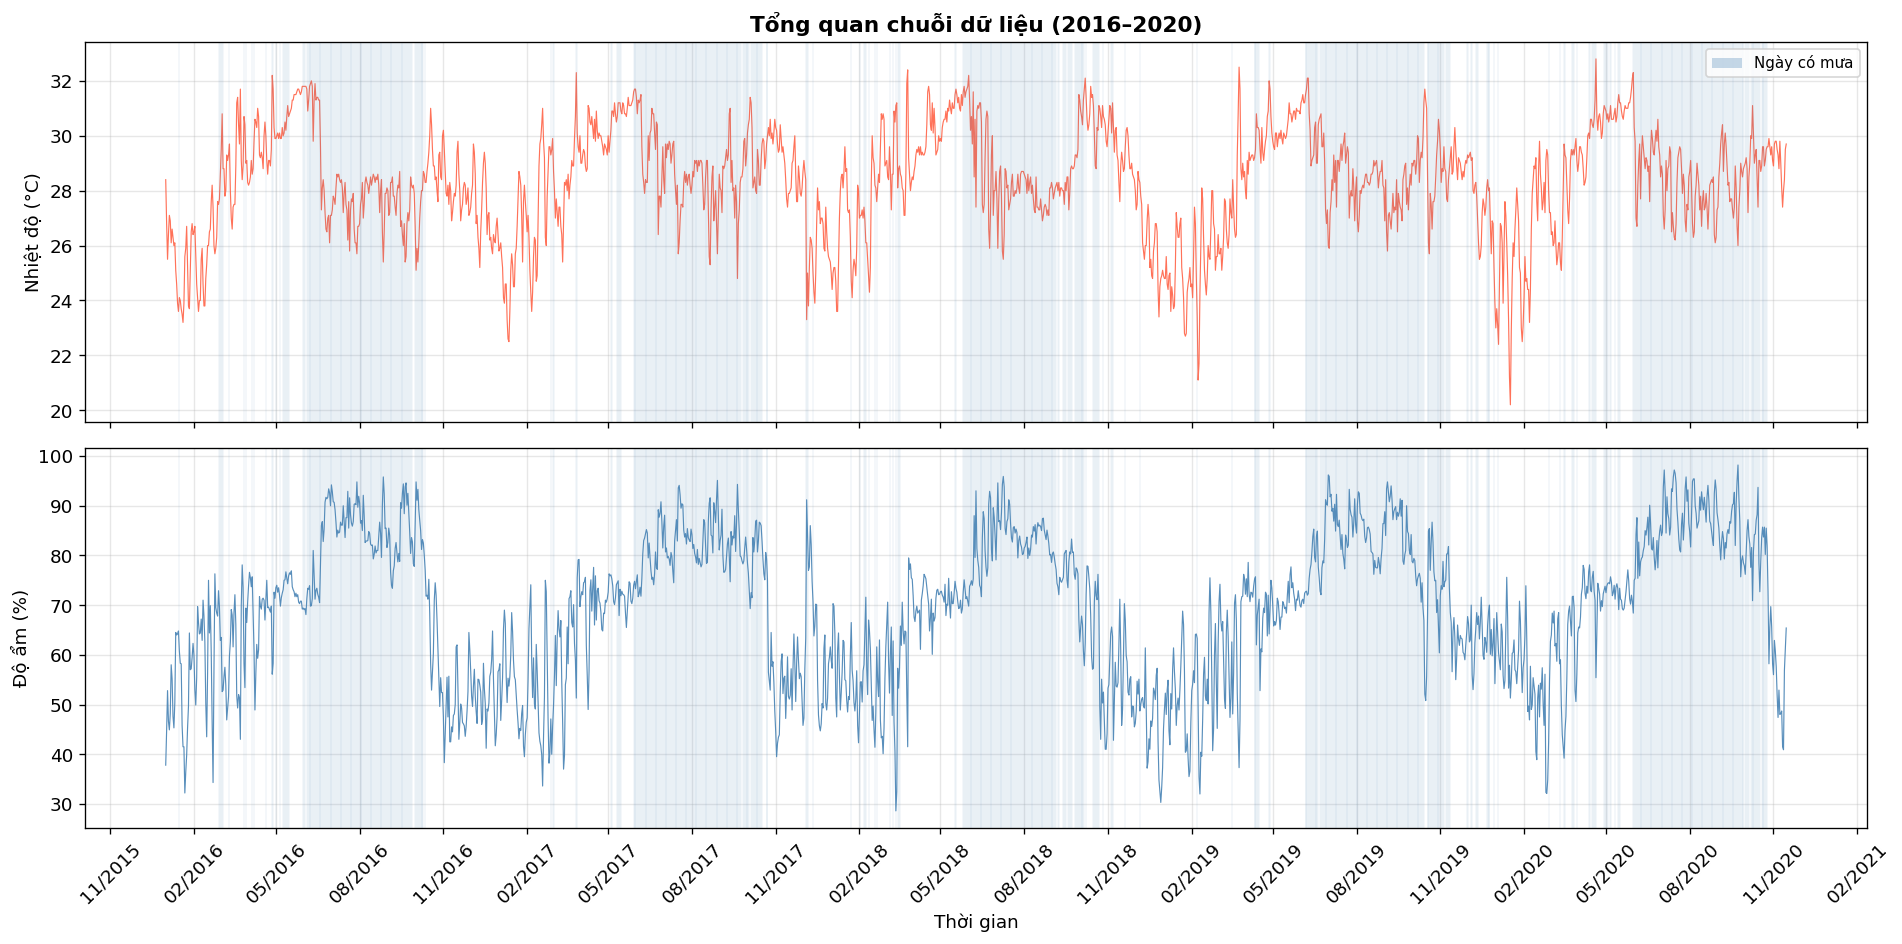


 Data Understanding hoàn tất — sẵn sàng sang EDA!


In [13]:
# ── 0.7 Biểu đồ tổng quan nhanh (Quick Overview Plot) ──
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Nhiệt độ
axes[0].plot(df_raw['datetime'], df_raw['temp'],
             color='tomato', linewidth=0.7, alpha=0.9)
axes[0].set_ylabel('Nhiệt độ (°C)', fontsize=11)
axes[0].set_title('Tổng quan chuỗi dữ liệu (2016–2020)', fontsize=13, fontweight='bold')

# Mưa: tô nền
rain_days = df_raw[df_raw['preciptype'] == 1]['datetime']
for d in rain_days:
    axes[0].axvline(d, color='steelblue', alpha=0.07, linewidth=1)
    axes[1].axvline(d, color='steelblue', alpha=0.07, linewidth=1)

# Độ ẩm
axes[1].plot(df_raw['datetime'], df_raw['humidity'],
             color='steelblue', linewidth=0.7, alpha=0.9)
axes[1].set_ylabel('Độ ẩm (%)', fontsize=11)
axes[1].set_xlabel('Thời gian', fontsize=11)

# Legend chú thích
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.3, label='Ngày có mưa')
]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=9)

import matplotlib.dates as mdates
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig_overview.png', bbox_inches='tight')
plt.show()

print("\n Data Understanding hoàn tất — sẵn sàng sang EDA!")
